# Heart Diseases Dataset - Decision Tree

In this notebook, we apply a Decision Tree classifier to the Heart Disease Cleveland dataset.

The preprocessed data is loaded directly from the CSV files generated in the preprocessing notebook.

This notebook covers:
- loading the preprocessed train and test sets
- training a Decision Tree with different criteria (Gini and Entropy)
- testing different tree depths to analyze overfitting
- evaluating the model using K-Fold Cross Validation
- evaluating the model using accuracy, confusion matrix, and classification report
- visualizing the decision tree structure
- analyzing feature importance

## 1. Load Libraries

In this section, the required libraries are imported.

- `pandas` is used for loading and handling the preprocessed CSV files
- `numpy` is used for numerical operations
- `matplotlib` and `seaborn` are used for visualization
- `DecisionTreeClassifier` is the main model used in this notebook
- `plot_tree` is used to visualize the tree structure
- `accuracy_score`, `confusion_matrix`, and `classification_report` are used to evaluate the model
- `cross_val_score` and `StratifiedKFold` are used to validate model stability

In [107]:
#pandas for data manipulation
import pandas as pd
#numpy for the numerical operations
import numpy as np

#matplotlib and seaborn for visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Importing for decision Tree model and visualization tool
from sklearn.tree import DecisionTreeClassifier, plot_tree
#Import evaluation metrics
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)
#Import cross-validation tools
from sklearn.model_selection import cross_val_score, StratifiedKFold


## 2. Load Preprocessed Data

The training and testing sets are loaded from the CSV files exported by the preprocessing notebook.

Two versions are available:
- raw data (without scaling) — used for the Decision Tree
- scaled data — used for the BPN

Since Decision Tree models split data based on threshold rules rather than distances or gradients,
feature scaling is not required.

For this reason, the raw version is used here.

The `.ravel()` function is applied to the target variable to convert it from a column vector to a 1D array,
which is the format expected by scikit-learn.


In [108]:
# Load raw train and test sets (no scaling needed for Decision Tree)
X_train = pd.read_csv("../Preprocessing/X_train_raw.csv")
X_test  = pd.read_csv("../Preprocessing/X_test_raw.csv")
y_train = pd.read_csv("../Preprocessing/y_train.csv").values.ravel()
y_test  = pd.read_csv("../Preprocessing/y_test.csv").values.ravel()

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (212, 18)
X_test shape:  (91, 18)
y_train shape: (212,)
y_test shape:  (91,)


#### Output Analysis — Load Preprocessed Data

- **212 samples for training (70%)** and **91 for testing (30%)**, out of 303 total patients
- **18 columns** confirm that One-Hot Encoding was applied correctly in preprocessing — expanded from 13 original columns after encoding `cp`, `restecg`, `thal`, and `slope`
- **y_train and y_test are 1D vectors** `(212,)` and `(91,)` — correct format expected by scikit-learn after applying `.ravel()`


## 3. Base Model — Decision Tree with Gini

A Decision Tree classifier is trained using the Gini impurity criterion with no depth limit.

Gini impurity measures how often a randomly chosen element would be incorrectly classified.
The tree selects the split that minimizes this value at each node.

- `criterion='gini'` sets the splitting criterion
- `random_state=42` ensures reproducibility

Both training and testing accuracy are reported to detect possible overfitting.
When training accuracy is significantly higher than testing accuracy, the model is likely overfitting.

In [109]:
#Initializing DT with Gini criterion and no depth limit
dt = DecisionTreeClassifier(criterion='gini', random_state=42)
#Training the model on the training set
dt.fit(X_train, y_train)

#Evaluates on training and testing sets
train_acc = accuracy_score(y_train, dt.predict(X_train))
test_acc  = accuracy_score(y_test,  dt.predict(X_test))

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

Train Accuracy: 1.0000
Test  Accuracy: 0.7473


#### Output Analysis — Base Model (Gini, no depth limit)

- **Train Accuracy: 1.0000** — the model classified every training sample
  correctly, which is a clear sign of **overfitting**
- **Test Accuracy: 0.7473** — performance drops significantly on unseen data,
  confirming the model memorized the training set instead of learning
  general patterns
- A gap of **~25%** between train and test accuracy indicates the tree grew
  too deep, fitting noise and specific details of the training set
- This justifies the need to control tree depth using `max_depth`,
  which is explored in the next section

## 4. Gini vs Entropy

Two splitting criteria are compared:

- **Gini impurity**: measures the probability of incorrect classification at a given node
- **Entropy (Information Gain)**: measures the amount of information gained by a split

In practice, both criteria often produce similar results.
This comparison helps determine which one performs better on this specific dataset.

In [110]:
#Comparing Gini and Entropy criteria
print("Criterion  | Train Accuracy | Test Accuracy")
print("-" * 45)

for criterion in ['gini', 'entropy']:
    model = DecisionTreeClassifier(criterion=criterion, random_state=42)
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    print(f"{criterion:8s} → Train: {tr:.4f} | Test: {te:.4f}")

Criterion  | Train Accuracy | Test Accuracy
---------------------------------------------
gini     → Train: 1.0000 | Test: 0.7473
entropy  → Train: 1.0000 | Test: 0.7143


#### Output Analysis — Gini vs Entropy

- Both criteria reach **Train Accuracy: 1.0000**, confirming that without
  a depth limit any tree will overfit regardless of the splitting criterion
- **Gini (0.7473) outperforms Entropy (0.7143)** on the test set,
  meaning it generalizes slightly better on this dataset
- The difference of ~3% suggests that Gini's tendency to favor larger
  class splits works better than Entropy's balanced splits for
  the Heart Disease classification task
- Based on this comparison, **Gini is selected** as the criterion
  for all subsequent models

## 5. Effect of max_depth

The depth of the tree controls how many levels of splits are allowed.

- A tree with no depth limit (`max_depth=None`) can grow until every leaf is pure,
  which often leads to overfitting on the training data
- A shallower tree generalizes better but may underfit if too restricted

Four depth values are tested: 3, 5, 7, and None.

Both training and testing accuracy are recorded for each configuration and plotted
to visualize the bias-variance tradeoff.

max_depth  | Train Accuracy | Test Accuracy
---------------------------------------------
max_depth=3    → Train: 0.8585 | Test: 0.7912
max_depth=5    → Train: 0.9387 | Test: 0.7473
max_depth=7    → Train: 0.9906 | Test: 0.7582
max_depth=None → Train: 1.0000 | Test: 0.7473


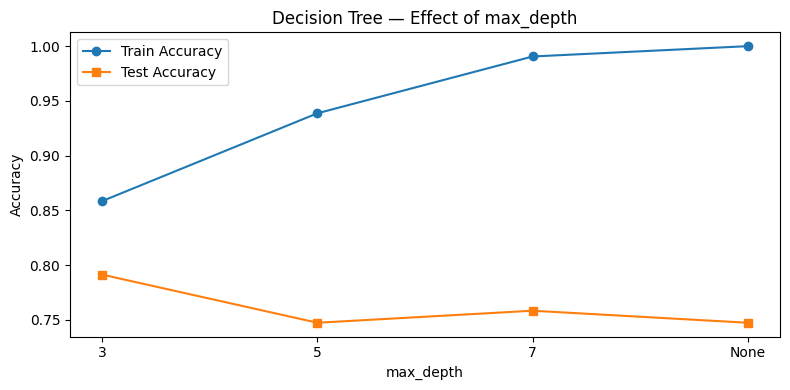

In [111]:
#Testing  different max_depth values
depths = [3, 5, 7, None]
results = []

print("max_depth  | Train Accuracy | Test Accuracy")
print("-" * 45)

for d in depths:
    model = DecisionTreeClassifier(criterion='gini',
                                   max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    tr = accuracy_score(y_train, model.predict(X_train))
    te = accuracy_score(y_test,  model.predict(X_test))
    results.append({'max_depth': str(d), 'train': tr, 'test': te})
    print(f"max_depth={str(d):4s} → Train: {tr:.4f} | Test: {te:.4f}")

#Graph the effect of max_depth on accuracy
res_df = pd.DataFrame(results)
x = range(len(res_df))
plt.figure(figsize=(8, 4))
plt.plot(x, res_df['train'], marker='o', label='Train Accuracy')
plt.plot(x, res_df['test'],  marker='s', label='Test Accuracy')
plt.xticks(x, res_df['max_depth'])
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree — Effect of max_depth')
plt.legend()
plt.tight_layout()
plt.show()

#### Output Analysis — Effect of max_depth

- As `max_depth` increases, **train accuracy grows consistently** toward 1.0,
  while **test accuracy decreases** — a clear illustration of overfitting
- **`max_depth=3` achieves the best test accuracy (0.7912)** with the smallest
  gap between train (0.8585) and test, indicating better generalization
- From `max_depth=5` onward, the model starts memorizing training data —
  train accuracy exceeds 93% while test accuracy drops below 75%
- The graph confirms the **bias-variance tradeoff**: shallower trees have
  higher bias but lower variance, which leads to better performance on
  unseen data for this dataset
- Based on these results, **`max_depth=3` is selected** as the best
  configuration for all subsequent evaluations

## 6. Best Model

Based on the depth comparison, a maximum depth of 3 is selected
as the best configuration.

This value provides a good balance between:
- fitting the training data well
- generalizing to unseen test data

The model is retrained with this configuration and used for all
subsequent evaluations.

In [112]:
#Retrain with the best configuration
best_dt = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
best_dt.fit(X_train, y_train)

#Generate predictions on the test set
y_pred = best_dt.predict(X_test)

print(f"Train Accuracy: {accuracy_score(y_train, best_dt.predict(X_train)):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Train Accuracy: 0.8585
Test  Accuracy: 0.7912


#### Output Analysis — Best Model (Gini, max_depth=3)

- **Train Accuracy: 0.8585** and **Test Accuracy: 0.7912** — the gap
  between train and test is now only ~7%, compared to ~25% with no depth limit
- This confirms that `max_depth=3` significantly reduces overfitting
  while maintaining solid predictive performance
- The model correctly classifies approximately **4 out of 5 patients**
  in the test set
- This configuration is used for all subsequent evaluations

## 7. Classification Report

The classification report provides a detailed evaluation of model
performance per class.

It includes:
- **Precision**: of all samples predicted as positive, how many were
  actually positive
- **Recall**: of all actual positive samples, how many were correctly
  identified
- **F1-score**: harmonic mean of precision and recall
- **Support**: number of actual samples per class

In a medical context, recall is especially important.
A false negative (predicting no disease when the patient actually has it)
is more costly than a false positive.

In [113]:
#Print the full classification report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Disease', 'Disease']))

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.76      0.90      0.82        49
     Disease       0.85      0.67      0.75        42

    accuracy                           0.79        91
   macro avg       0.80      0.78      0.78        91
weighted avg       0.80      0.79      0.79        91



#### Output Analysis — Classification Report

- **Overall accuracy: 0.79** — the model correctly classifies 79% of
  the 91 test patients
- **No Disease — Recall: 0.90**: the model correctly identifies 90% of
  healthy patients, generating very few false alarms
- **Disease — Recall: 0.67**: the model only detects 67% of patients
  who actually have heart disease — meaning **3 out of every 10 sick
  patients are missed**
- In a medical context, this is the most critical metric — a **False
  Negative** (sick patient classified as healthy) is far more dangerous
  than a False Positive
- **Disease — Precision: 0.85**: when the model does predict disease,
  it is correct 85% of the time
- The model shows a tendency to be more conservative — it favors
  predicting "No Disease", which explains the high recall for that
  class but the lower recall for Disease
- Improving Disease recall should be the main objective if this model
  were to be used in a real clinical setting

## 8. K-Fold Cross Validation

A single train/test split can be influenced by how the data was divided.
To verify that the model performance is consistent and not the result
of a lucky split, K-Fold Cross Validation is applied.

The training data is divided into 5 folds. In each iteration, one fold
is used as the validation set and the remaining four are used for training.
This process repeats 5 times, each time using a different fold.

StratifiedKFold is used to preserve the class distribution in each fold,
which is important for classification problems.

A low standard deviation means the model performs consistently
regardless of how the data is split.

In [114]:
# Use StratifiedKFold to preserve class distribution in each fold
# This is important for classification problems, as the TA explained in class
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Apply cross-validation on the best model using the training set only
cv_scores = cross_val_score(best_dt, X_train, y_train, cv=skf, scoring='accuracy')

print("Cross-validation scores per fold:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")

print(f"\nMean accuracy:       {cv_scores.mean():.4f}")
print(f"Standard deviation:  {cv_scores.std():.4f}")

Cross-validation scores per fold:
  Fold 1: 0.7907
  Fold 2: 0.8140
  Fold 3: 0.9048
  Fold 4: 0.7381
  Fold 5: 0.7857

Mean accuracy:       0.8066
Standard deviation:  0.0549


#### Output Analysis — K-Fold Cross Validation

- **Mean accuracy: 0.8066** across 5 folds — consistent with the
  0.7912 obtained on the single test set, confirming the result
  was not due to a lucky split
- **Standard deviation: 0.0549** — relatively low, indicating the
  model performs **consistently across different data splits**
- Fold 3 (0.9048) stands out as the highest — likely due to a
  particularly favorable class distribution in that fold
- Fold 4 (0.7381) is the lowest, showing the model's performance
  can vary depending on which samples are used for validation
- Overall, the cross-validation confirms that **`max_depth=3` is
  a robust configuration** for this dataset, not just for one
  specific train/test split

##### CMT:Por qué StratifiedKFold y no KFold normal?
La TA mostró StratifiedKFold específicamente para clasificación — garantiza que cada fold tenga la misma proporción de clases (54% sin enfermedad, 46% con enfermedad) en lugar de hacer un split puramente aleatorio. Es exactamente lo que explica el slide de "Stratified K Fold Cross Validation" que te mandó la TA.

## 9. Confusion Matrix

While K-Fold Cross Validation confirmed that the model performs
consistently across different data splits, the confusion matrix
provides a detailed view of the specific errors made on the final test set.

- **True Positives (TP)**: disease correctly predicted as disease
- **True Negatives (TN)**: no disease correctly predicted as no disease
- **False Positives (FP)**: no disease incorrectly predicted as disease
- **False Negatives (FN)**: disease incorrectly predicted as no disease

In a clinical setting, False Negatives are the most critical error,
as they represent patients with heart disease who were not identified
by the model.

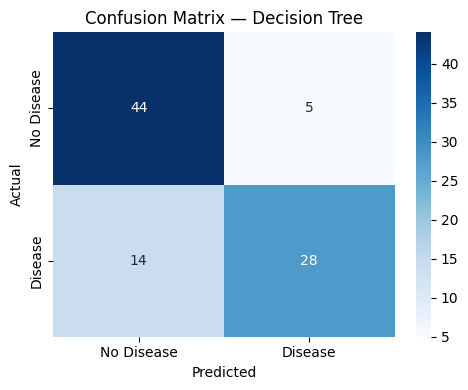

In [115]:
#Computes and plots the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — Decision Tree')
plt.tight_layout()
plt.show()

#### Output Analysis — Confusion Matrix

- **True Negatives (44)**: healthy patients correctly identified as healthy
- **True Positives (28)**: sick patients correctly identified as sick
- **False Positives (5)**: healthy patients incorrectly predicted as sick
  — low clinical risk, leads to unnecessary check-ups
- **False Negatives (14)**: sick patients incorrectly predicted as healthy
  — the most critical error in a medical context, as these patients
  would leave without a diagnosis
- The model misses **14 out of 42 disease cases (33%)**, which is
  consistent with the Disease recall of 0.67 from the classification report
- The relatively low number of False Positives (5) confirms the model
  is conservative — it tends to predict "No Disease" when uncertain,
  prioritizing specificity over sensitivity
- In a real clinical deployment, reducing False Negatives would be
  the main optimization target, potentially by adjusting the
  classification threshold or applying class weighting

## 10. Feature Importance

Feature importance indicates how much each variable contributed
to the model's decisions.

Higher values mean the feature was used more frequently and at higher
levels of the tree, making it more influential in the classification.

This analysis helps understand which medical indicators are most relevant
for predicting heart disease in this dataset.

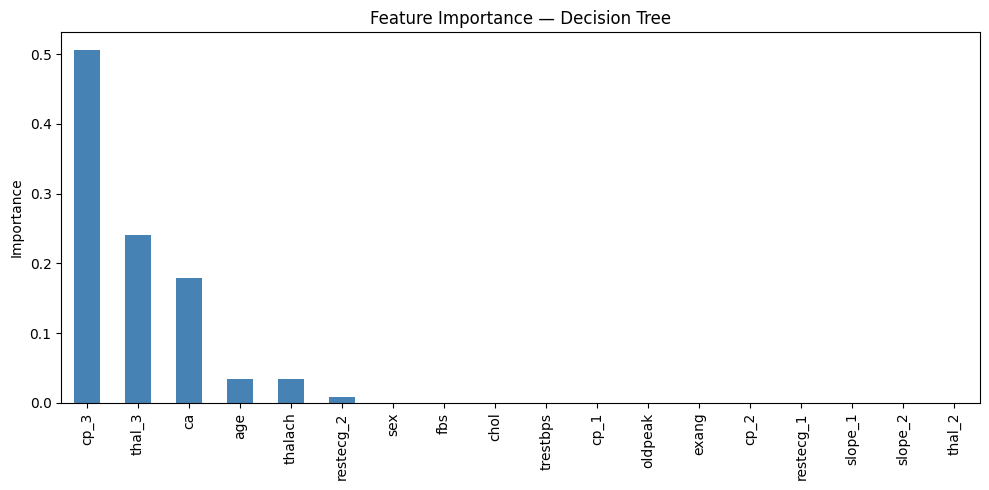

cp_3         0.505868
thal_3       0.240244
ca           0.178593
age          0.033756
thalach      0.033392
restecg_2    0.008148
sex          0.000000
fbs          0.000000
chol         0.000000
trestbps     0.000000
cp_1         0.000000
oldpeak      0.000000
exang        0.000000
cp_2         0.000000
restecg_1    0.000000
slope_1      0.000000
slope_2      0.000000
thal_2       0.000000
dtype: float64


In [116]:
#Compute and plot feature importance
importances = pd.Series(best_dt.feature_importances_,
                         index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue')
plt.title('Feature Importance — Decision Tree')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(importances)

#### Output Analysis — Feature Importance

- **cp_3 (0.5059)**: the most influential feature by far — represents
  asymptomatic chest pain, which is clinically known as one of the
  strongest indicators of heart disease
- **thal_3 (0.2402)**: second most important — represents a reversible
  thalassemia defect, a direct measure of heart blood flow abnormality
- **ca (0.1786)**: third — number of major vessels colored by fluoroscopy,
  a direct indicator of arterial blockage
- Together, these **3 features account for ~92% of the model's decisions**
- **12 out of 18 features have zero importance** — the tree with
  `max_depth=3` only needed 6 features to make all its splits,
  which is consistent with a shallow tree
- Features like `chol`, `trestbps`, `sex`, and `oldpeak` — often
  considered relevant in cardiovascular studies — were not used,
  likely because the top 3 features were already sufficient to
  separate the classes at this depth
- These results are **clinically meaningful**: the three most important
  features are all direct measures of cardiac function, not indirect
  risk factors

## 11. Decision Tree Visualization

The decision tree structure is visualized to show how the model
makes its decisions at each node.

Each node displays:
- the feature and threshold used for the split
- the Gini impurity at that node
- the number of samples reaching that node
- the predicted class

The color intensity indicates class purity — darker nodes are closer
to a single class.

This visualization is useful for interpreting the model and understanding
which features drive the classification at the top levels of the tree.

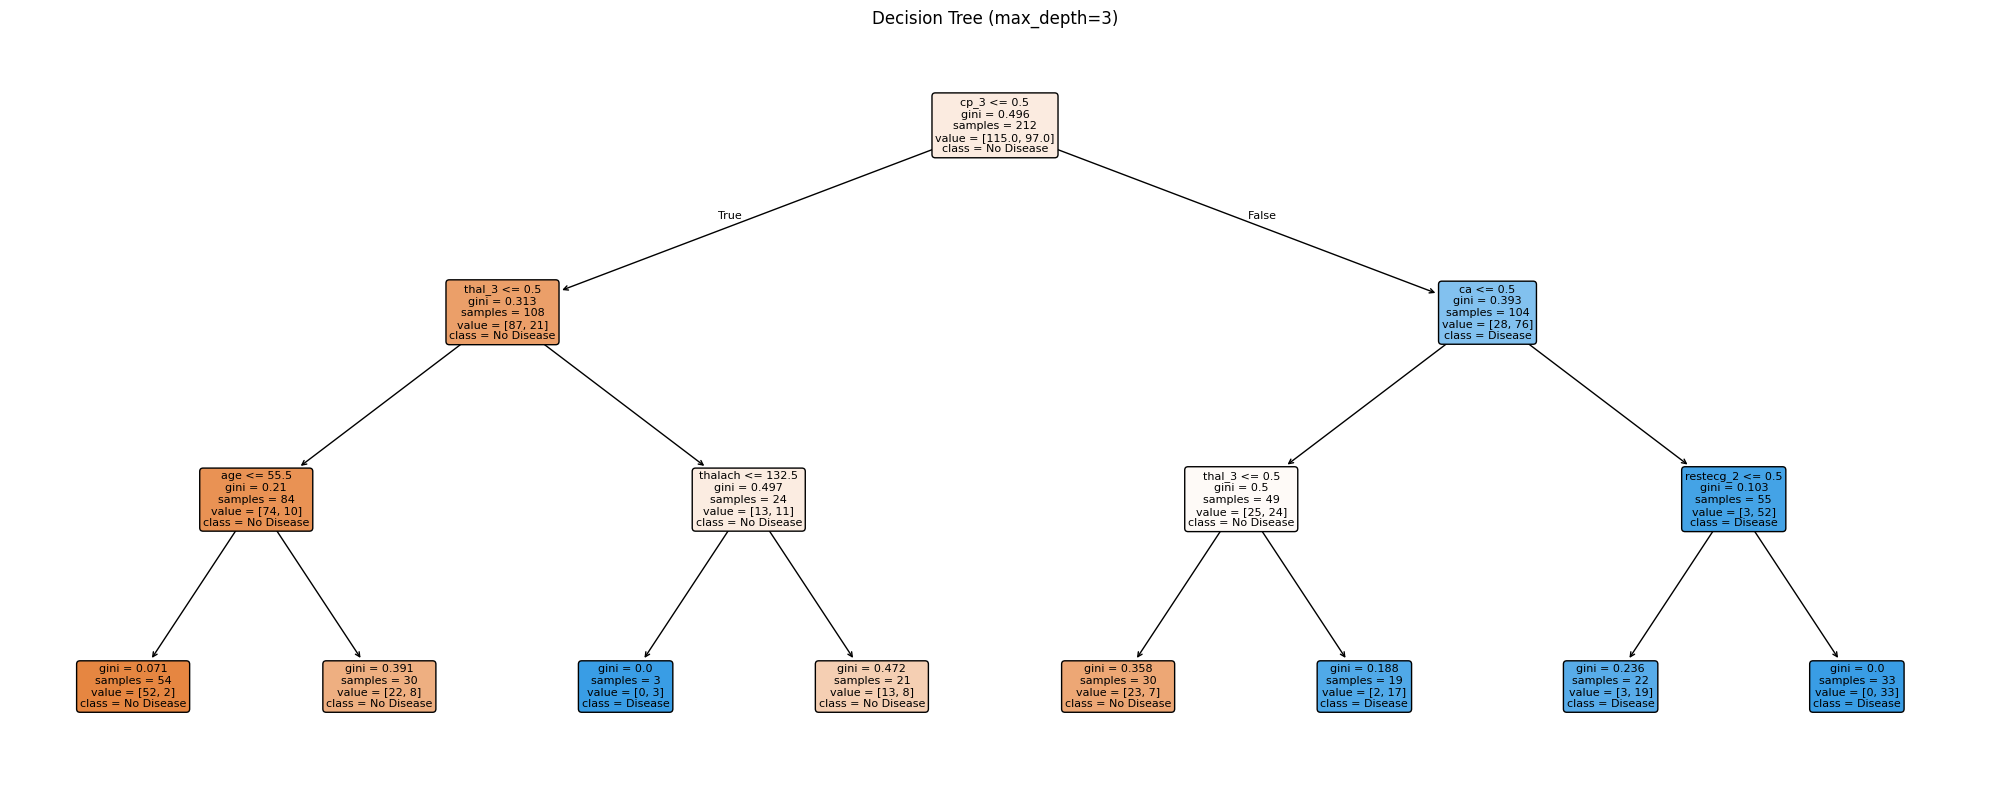

In [119]:
#Visualize the decision tree structure
plt.figure(figsize=(20, 8))
plot_tree(best_dt,
          feature_names=X_train.columns,
          class_names=['No Disease', 'Disease'],
          filled=True, rounded=True, fontsize=8)

plt.title('Decision Tree (max_depth=3)')
plt.tight_layout()
plt.show()

## Output Analysis — Decision Tree Visualization

- The **root node splits on `cp_3 <= 0.5`** — confirming it as the
  most informative feature, consistent with the feature importance results
- **Left branch (True — no asymptomatic chest pain)**: the tree
  initially predicts "No Disease" and refines using `thal_3` and `age`
- **Right branch (False — asymptomatic chest pain present)**: the tree
  shifts toward "Disease" and refines using `ca` and `restecg_2`
- **Leaf nodes with gini = 0.0** represent perfectly pure nodes —
  the tree classifies those samples with complete certainty
  (e.g. `value = [0, 3]` means 3 Disease samples, 0 No Disease)
- **Orange nodes** → majority class is No Disease
- **Blue nodes** → majority class is Disease
- The tree logic is **clinically meaningful**: asymptomatic chest pain
  leads to suspicion of disease, which is then confirmed by checking
  vessel blockage (`ca`) and ECG results (`restecg_2`)
- Only 4 features appear across all splits (`cp_3`, `thal_3`,
  `age`, `thalach`, `ca`, `restecg_2`), consistent with the
  zero-importance features observed earlier